# Slow Dynamics and High Variability in Networks with Clustered Connections




In [1]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import solve_ivp
from dataclasses import dataclass
from typing import Tuple
from matplotlib.ticker import ScalarFormatter

# Initialize default model parameters

In [2]:
@dataclass
class ClusterParams:
    enabled: bool = False
    R_ee: float = 1.0 # ratio of p_in / p_out. 1.0 implies no clustering
    cluster_size: int = 80 # num neurons in each cluster
    weight_scaling_factor: float = 1.9 # ƒactor to scale excitatory synaptic weight for in-cluster connections

    # TODO: Is this correct?
    def calculate_p_in_out(self, N_E: int, p_avg: float) -> Tuple[float, float]:
        # Use within-cluster pair probability (exclude self)
        p_same = (self.cluster_size - 1) / (N_E - 1)

        # Enforce: p_avg = p_same * p_in + (1 - p_same) * p_out
        # and p_in = R_ee * p_out
        denom = p_same * self.R_ee + (1 - p_same)
        p_out = p_avg / denom
        p_in = self.R_ee * p_out

        return p_in, p_out


class ModelParams:
    """Parameters for the clustered network model."""
    
    def __init__(
        self,
        # Network size
        N_E=4000,              # number of excitatory neurons
        N_I=1000,              # number of inhibitory neurons
        N_ref=5000,            # reference network size (for weight scaling)
        seed=42,               # random seed
        # Neuron parameters
        refractory_t=5*ms,     # refractory period
        tau_e=15*ms,           # membrane time constant for E neurons
        tau_i=10*ms,           # membrane time constant for I neurons
        Vt=1,                  # spike threshold
        Vr=0,                  # reset potential
        # Synaptic time constants
        tau_1=1*ms,               # exponential filter time constant 1
        tau2_e=3*ms,             # exponential filter time constant 2 (excitatory)
        tau2_i=2*ms,             # exponential filter time constant 2 (inhibitory)
        # Reference synaptic weights (calibrated for N=5000)
        j_ee_ref=0.024,        # E -> E
        j_ie_ref=0.014,        # E -> I 
        j_ei_ref=-0.045,       # I -> E (negative for inhibition)
        j_ii_ref=-0.057,       # I -> I
        # Connection probabilities
        p_conn_e=0.2,          # E -> E connection probability
        p_conn_i=0.5,          # connection probability involving I
        # Mean equilibrium
        mu_e_range=(1.1, 1.2),    # external input range for E neurons
        mu_i_range=(1.0, 1.05),   # external input range for I neurons

        # Simulation parameters
        dt=0.1*ms,             # integration timestep
        analysis_start_t=1.5*second, # time to start statistical analysis
        analysis_window_t=1.5*second, # time window to perform statistical analysis
        duration=3*second,     # simulation duration
        # Plotting
        voltage_scale=15*volt, # for converting to physical units
    ):
        self.N_E = N_E
        self.N_I = N_I
        self.N_ref = N_ref
        self.seed = seed
        self.refractory_t = refractory_t
        self.tau_m_e = tau_e
        self.tau_m_i = tau_i
        self.Vt = Vt
        self.Vr = Vr
        self.tau1 = tau_1
        self.tau2_e = tau2_e
        self.tau2_i = tau2_i
        self.j_ee_ref = j_ee_ref
        self.j_ei_ref = j_ei_ref
        self.j_ie_ref = j_ie_ref
        self.j_ii_ref = j_ii_ref
        self.p_conn_e = p_conn_e
        self.p_conn_i = p_conn_i
        self.mu_e_range = mu_e_range
        self.mu_i_range = mu_i_range
        self.dt = dt
        self.analysis_start_t = analysis_start_t
        self.analysis_window_t = analysis_window_t
        self.duration = duration
        self.voltage_scale = voltage_scale
    
    @property
    def N_total(self):
        """Total number of neurons."""
        return self.N_E + self.N_I
    
    @property
    def scaled_weights(self):
        """
        Scale synaptic weights based on network size.
        
        Weights scale as 1/sqrt(N) to maintain constant variance 
        of total synaptic input as network size changes.
        """
        scale_factor = np.sqrt(self.N_ref / self.N_total) # TODO: Not sure about using N_ref here
        return (
            self.j_ee_ref * scale_factor,
            self.j_ei_ref * scale_factor,
            self.j_ie_ref * scale_factor,
            self.j_ii_ref * scale_factor,
        )
    
    def get_rng(self):
        """Return a numpy random generator with the configured seed."""
        return np.random.default_rng(seed=self.seed)

# Setup the base model

In [22]:
class NeuronNetwork:
    def __init__(self, params: ModelParams, clustering_params: ClusterParams):
        self.params = params
        self.cluster_params = clustering_params
        self.rng = params.get_rng()
        self._initialize()

    def _initialize(self):
        start_scope()

        params = self.params
        cluster_params = self.cluster_params
        rng = self.rng

        # Unpack scaled weights
        j_ee, j_ei, j_ie, j_ii = params.scaled_weights
        tau1 = params.tau1

        # Set up equations
        eqs_base = """
        dV/dt = (mu - V) / tau_m + Isyn : 1 (unless refractory)
        Isyn = g : 1/second
        dg/dt = (x - g) / tau_2 : 1/second
        dx/dt = -x / tau_1 : 1/second

        mu : 1      # per-neuron bias (external input)
        tau_m : second  # per-neuron membrane time constant
        tau_1 : second # varies depending on inhibitory or excitatory neuron
        tau_2 : second # varies depending on inhibitory or excitatory neuron
        """

        # Excitatory population
        E = NeuronGroup(
            params.N_E,
            eqs_base,
            threshold=f'V > {params.Vt}',
            reset=f'V = {params.Vr}',
            refractory=params.refractory_t,
            method='euler',
            dt=params.dt
        )
        # Inhibitory population
        I = NeuronGroup(
            params.N_I,
            eqs_base,
            threshold=f'V > {params.Vt}',
            reset=f'V = {params.Vr}',
            refractory=params.refractory_t,
            method='euler',
            dt=params.dt
        )

        # Set up bias and initial voltages randomly
        E.mu = rng.uniform(*params.mu_e_range, size=params.N_E)
        E.V = rng.uniform(params.Vr, params.Vt, size=params.N_E)
        I.mu = rng.uniform(*params.mu_i_range, size=params.N_I)
        I.V = rng.uniform(params.Vr, params.Vt, size=params.N_I)

        # Set time constants
        E.tau_m = params.tau_m_e
        E.tau_1 = params.tau1
        E.tau_2 = params.tau2_e
        I.tau_m = params.tau_m_i
        I.tau_1 = params.tau1
        I.tau_2 = params.tau2_i

        # Set up synapses for connections involving inhibitory neurons
        S_ie = Synapses(E, I, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)
        # I -> E
        S_ei = Synapses(I, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)
        # I -> I
        S_ii = Synapses(I, I, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)

        # Connect inhibitory synapses (same probability for all)
        S_ei.connect(p=params.p_conn_i)
        S_ie.connect(p=params.p_conn_i)
        S_ii.connect(p=params.p_conn_i)

        S_ie.w = j_ie
        S_ei.w = j_ei
        S_ii.w = j_ii

        self.S_ee = None
        self.S_ee_in = None
        self.S_ee_out = None

        # E -> E connections: handle clustering if enabled
        # Uses a single Synapses object with cluster-aware connectivity
        if cluster_params.enabled:
            S_ee_in = Synapses(E, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)
            S_ee_out = Synapses(E, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)

            p_in, p_out = cluster_params.calculate_p_in_out(params.N_E, params.p_conn_e)

            # Connect with different probabilities based on cluster membership
            S_ee_in.connect(
                condition='i // cluster_size == j // cluster_size',
                p='p_in',
                namespace={'p_in': p_in, 'p_out': p_out, 'cluster_size': cluster_params.cluster_size}
            )

            S_ee_out.connect(
                condition='i // cluster_size != j // cluster_size',
                p='p_out',
                namespace={'p_in': p_in, 'p_out': p_out, 'cluster_size': cluster_params.cluster_size}
            )

            # Set weights: stronger for within-cluster, baseline for between-cluster
            S_ee_in.w = j_ee * cluster_params.weight_scaling_factor
            S_ee_out.w = j_ee

            self.S_ee_in = S_ee_in
            self.S_ee_out = S_ee_out
        else:
            S_ee = Synapses(E, E, 'w: 1', on_pre='x_post += w/tau_1', dt=params.dt)

            # No clustering: uniform connectivity
            #E.cluster_id = 0  # all neurons in "cluster 0"
            S_ee.connect(condition='i != j', p=params.p_conn_e)
            S_ee.w = j_ee

            self.S_ee = S_ee

        # --- Monitors ---
        state_monitor_e = StateMonitor(E, variables=['V', 'x'], record=[0, 1, 2])
        state_monitor_i = StateMonitor(I, variables=['V', 'x'], record=[0, 1, 2])
        spike_monitor_e = SpikeMonitor(E)
        spike_monitor_i = SpikeMonitor(I)

        self.E = E
        self.I = I
        self.S_ie = S_ie
        self.S_ei = S_ei
        self.S_ii = S_ii
        self.state_monitor_e = state_monitor_e
        self.state_monitor_i = state_monitor_i
        self.spike_monitor_e = spike_monitor_e
        self.spike_monitor_i = spike_monitor_i

        network_objects = [E, I, S_ie, S_ei, S_ii, state_monitor_e, state_monitor_i, spike_monitor_e, spike_monitor_i]
        if self.S_ee is not None:
            network_objects.append(self.S_ee)
        if self.S_ee_in is not None:
            network_objects.append(self.S_ee_in)
        if self.S_ee_out is not None:
            network_objects.append(self.S_ee_out)
        self.network = Network(*network_objects)


        self.network.store('initial') # Persist the initial configuration

    def run(self):
        self.network.restore('initial') # On every run call, restore initial configuration
        self.network.run(self.params.duration)

    def spikes(self):
        return self.spike_monitor_e, self.spike_monitor_i


def firing_rate(spike_monitor, num_in_population, start_t, window_t):
    """Calculate firing rate for each neuron in a population.
    
    Args:
        spike_monitor: Brian2 SpikeMonitor object
        num_in_population: Number of neurons in the population
        start_t: Start time for analysis window
        window_t: Duration of analysis window
    
    Returns:
        Array of firing rates (spikes/second) for each neuron
    """
    mask = (spike_monitor.t >= start_t) & (spike_monitor.t <= start_t + window_t)
    spikes = spike_monitor.i[mask]
    spike_counts = np.bincount(spikes, minlength=num_in_population)
    return spike_counts / window_t

# Run and plot an un-clustered network

In [4]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=1.0)

unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

WARNING    Removing unsupported flag '-w' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-O3' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-ffast-math' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-fno-finite-math-only' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-std=c++11' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Cannot use Cython, a test compilation failed: command 'x86_64-linux-gnu-g++' failed: No such file or directory (CompileError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtim

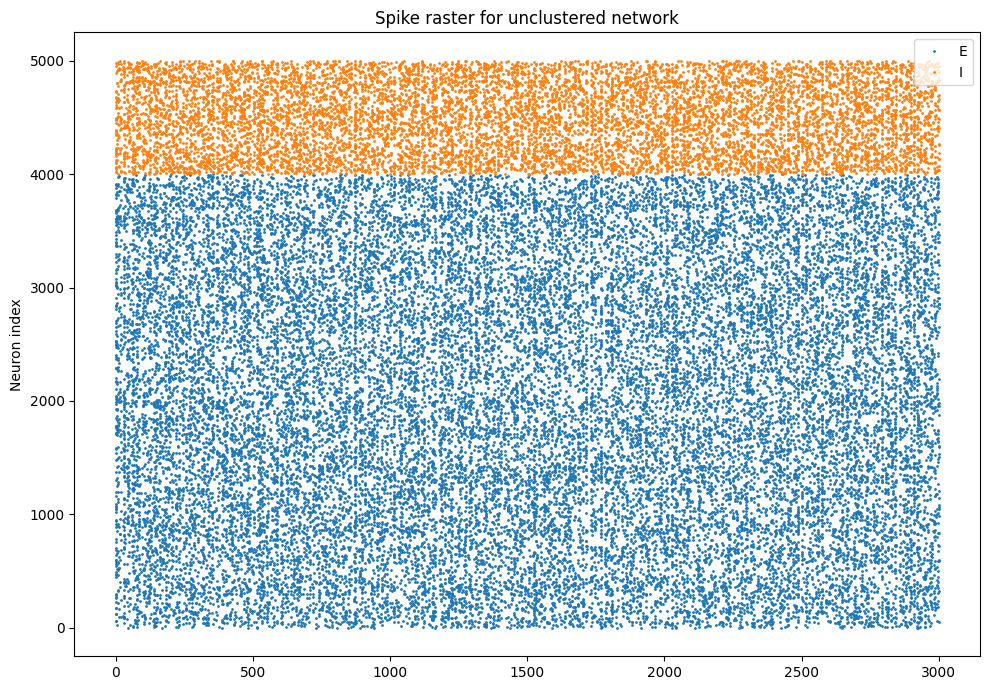

In [5]:
fig, axes = plt.subplots(figsize=(10, 7), sharex=True)

# Raster plot
axes.plot(unclustered_network.spike_monitor_e.t/ms, unclustered_network.spike_monitor_e.i, '.', markersize=2, label='E')
axes.plot(unclustered_network.spike_monitor_i.t/ms, unclustered_network.spike_monitor_i.i + params.N_E, '.', markersize=2, label='I')
axes.set_ylabel('Neuron index')
axes.set_title('Spike raster for unclustered network')
axes.legend(loc='upper right')

plt.tight_layout()
plt.show()

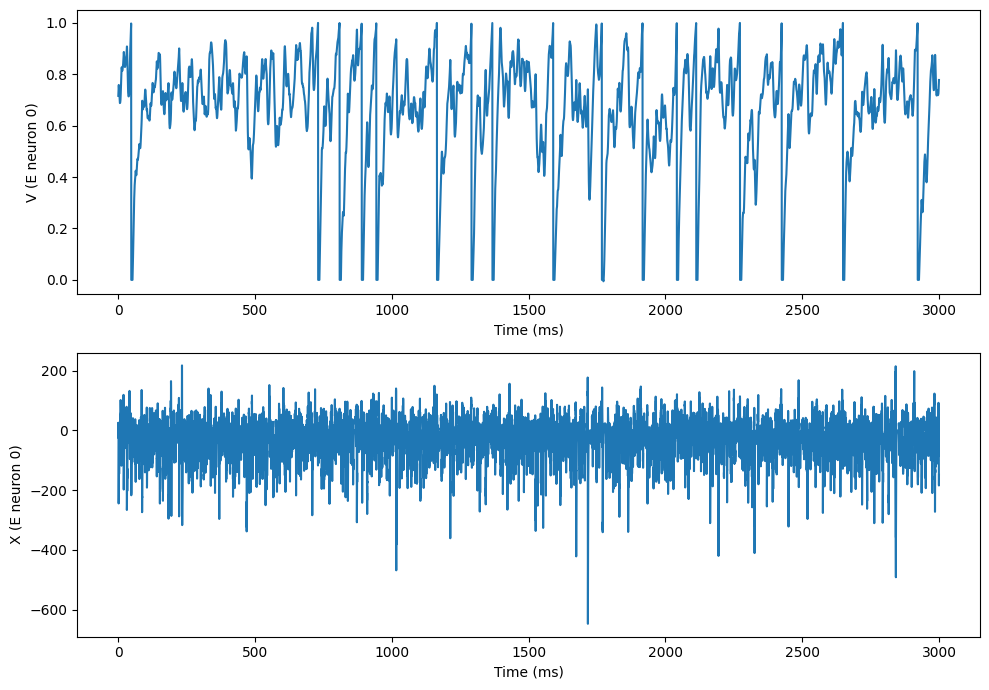

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()

# Run and plot a clustered network

In [7]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.5)

clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

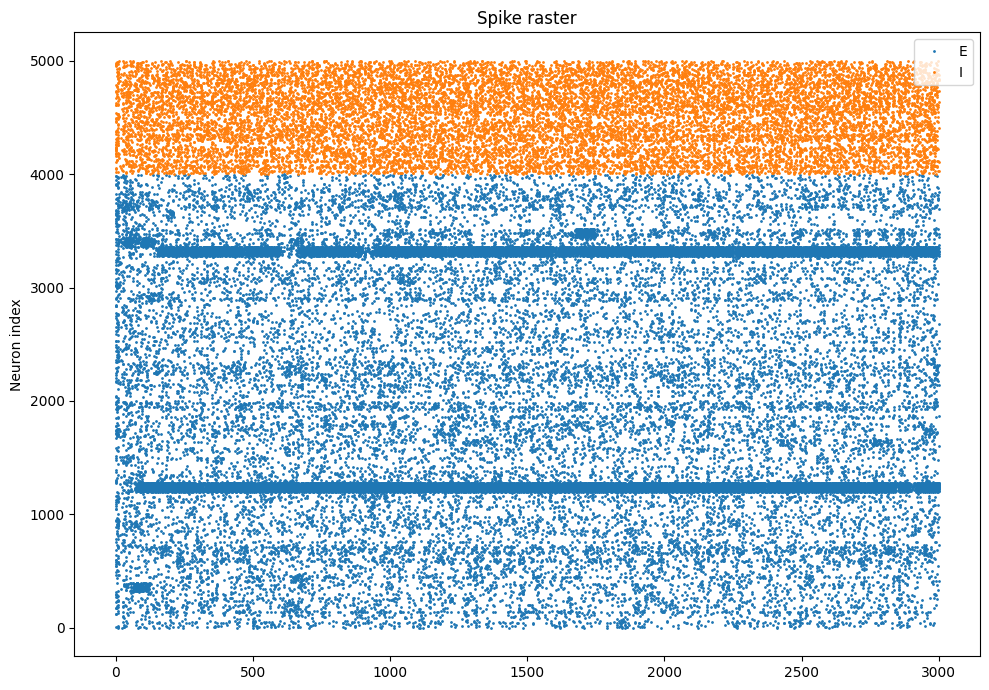

In [8]:
fig, axes = plt.subplots(figsize=(10, 7), sharex=True)

# Raster plot
axes.plot(clustered_network.spike_monitor_e.t/ms, clustered_network.spike_monitor_e.i, '.', markersize=2, label='E')
axes.plot(clustered_network.spike_monitor_i.t/ms, clustered_network.spike_monitor_i.i + params.N_E, '.', markersize=2, label='I')
axes.set_ylabel('Neuron index')
axes.set_title('Spike raster')
axes.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Plot the membrane potentials of a few neurons

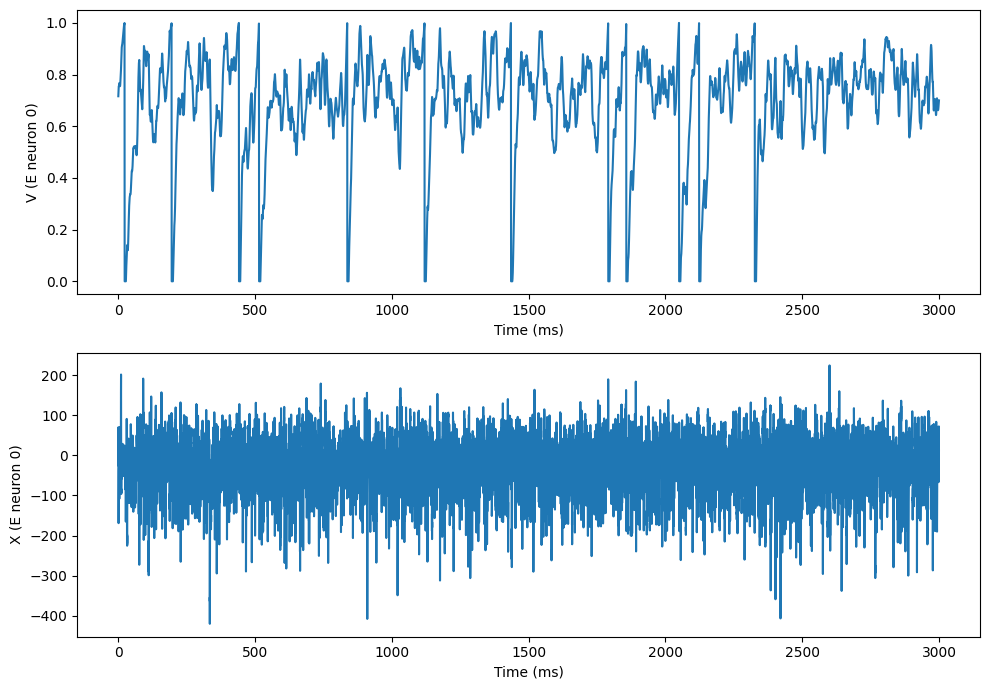

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

# Plotting the firing rate distribution

(4000,) (1000,)
(5000,)
(4000,) (1000,)
(5000,)


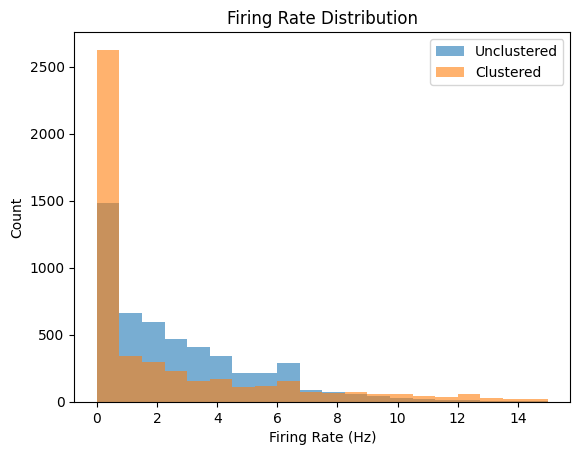

In [10]:
def plot_firing_rate_distribution(networks, labels, title, params):
    fig, ax = plt.subplots()

    firing_rates_by_label = {}
    for network, label in zip(networks, labels):
        firing_rates_e = firing_rate(
            network.spike_monitor_e,
            params.N_E,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        firing_rates_i = firing_rate(
            network.spike_monitor_i,
            params.N_I,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        print(firing_rates_e.shape, firing_rates_i.shape)

        rates = np.concatenate([firing_rates_e, firing_rates_i])
        print(rates.shape)

        firing_rates_by_label[label] = rates
        ax.hist(
            rates,
            bins=20,
            range=(0, 15),
            alpha=0.6,
            label=label,
        )

    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

    return firing_rates_by_label

firing_rates_by_label = plot_firing_rate_distribution(
    [unclustered_network, clustered_network],
    ["Unclustered", "Clustered"],
    title="Firing Rate Distribution",
    params=params,
)

# Checking difference of exponential filter to an ODE

In [11]:
# TODO
# def x_prime(x, t1):
#     return -x / t1

# def g_prime(g, x, t2):
#     return (x - g) / t2

# def filter(t, t1, t2):
#     return 1 / (t2 - t1) * (np.exp(-t / t2) - np.exp(-t / t1))

# def euler_solve(x0, t, t1):
#     """Simple Euler method for x' = -x/t1."""
#     x = np.zeros_like(t)
#     x[0] = x0
#     dt = t[1] - t[0]
#     for i in range(1, len(t)):
#         x[i] = x[i - 1] + dt * x_prime(x[i - 1], t1)
#     return x

# t1 = 5.0
# x0 = 1.0
# t = np.linspace(0.0, 30.0, 600)

# x_num = euler_solve(x0, t, t1)

# sol = solve_ivp(
#     lambda tau, y: x_prime(y, t1),
#     t_span=(t[0], t[-1]),
#     y0=[x0],
#     t_eval=t,
# )
# x_scipy = sol.y[0]

# x_exact = x0 * np.exp(-t / t1)

# fig, ax = plt.subplots()
# ax.plot(t, x_num, label="Euler (numerical)")
# ax.plot(t, x_scipy, label="SciPy solve_ivp")
# ax.plot(t, x_exact, "--", label="Exact")
# ax.set_xlabel("t")
# ax.set_ylabel("x")
# ax.legend()
# plt.show()

# # Plot the filter for a sample t2.
# t2 = 2.0

# fig, ax = plt.subplots()
# ax.plot(t, filter(t, t1, t2), label="filter(t)")
# ax.set_xlabel("t")
# ax.set_ylabel("filter")
# ax.legend()
# plt.show()


    

# Experiment

Now instead of looking at a single network, we follow the paper's protocol of testing the uniform and clutered networks across 12 different network realizations, with 9 trials for each realization. This enables statistical analysis on spike counts.

In [12]:
class Experiment():
    def __init__(self, realizations=12, trials=9, model_params=ModelParams()):
        self.realizations=realizations
        self.trials=trials
        self.uniform_networks: list[NeuronNetwork] = self._initialize_networks(realizations, model_params, ClusterParams(enabled=True, R_ee=1))
        self.spike_times = []
        self.neuron_ids = []

    def run(self):
        for n in self.uniform_networks:
            for trial in range(self.trials):
                n.run()
                self.spike_times.extend(n.spike_monitor_e.t)


    def _initialize_networks(self, realizations, model_params, cluster_params):
        networks = []
        for i in range(realizations):
            n = NeuronNetwork(model_params, cluster_params)
            networks.append(n)
        return networks


In [13]:
e = Experiment(realizations=2, trials=2)
e.run()
print(e.uniform_networks)



    

[<__main__.NeuronNetwork object at 0x75a71a2c5160>, <__main__.NeuronNetwork object at 0x75a71a385670>]


In [14]:
def fano_factor(e):
    # Collect spike counts from all trials of all network realizations, in the same window of time. 
    monitors = [n.spike_monitor_e for n in e.uniform_networks]

    # Comptue variance of spike count in this window across the trials for each neuron

    # Compute mean spike count for each neuron

    # Return fano factor for each neuron
    


# Correlation coefficients

In [8]:
seeds = np.random.randint(2,10000,12)
n_trials = 9

In [7]:
print(seeds)

[7558 5648 6621 6791 6357 5471 4696 5703  893 5359 6673 3764]


In [5]:
#Nr of spikes for neuron i over a sliding window
def window_spikes(spike_train, window, overlap, timerange):
    start_time = timerange[0]
    end_time = timerange[1]

    spikes = []
    while start_time + window <= end_time:
        left = np.searchsorted(spike_train, start_time, "left")
        right = np.searchsorted(spike_train, start_time+window, "right")

        n_spikes = right-left
        spikes.append(n_spikes)

        start_time += overlap
    
    return spikes

#Calculates variance and covariance for all of the neurons
def calc_var_cov(network, window, overlap, timerange):
    all_neuron_windows = []
    trains = network.spike_monitor_e.spike_trains()

    for i in range(params.N_E):
        train_i = trains[i]
        all_neuron_windows.append(window_spikes(train_i, window, overlap, timerange))

    window_counts = np.array(all_neuron_windows)
    cov_matrix = np.cov(window_counts, rowvar=True, bias=False)
    row_vars = np.var(window_counts, axis=1)

    return cov_matrix, row_vars

#Calculates the correlation coefficients
def calc_coeffs(cov_matrix, neuron_vars, params):
    coeffs = []
    for config in range(len(cov_matrix)):
        for i in range(params.N_E):
            for j in range(i+1,params.N_E):
                coeffs.append(cov_matrix[config][i][j] / np.sqrt(neuron_vars[config][i] * neuron_vars[config][j]))
    
    return np.array(coeffs)

#Function to calculate same cluster coefficients
def calc_cluster_coeffs(cov_matrix, neuron_vars, params, cluster_params):
    coeffs = []
    n_cluster = cluster_params.cluster_size
    for config in range(len(cov_matrix)):
        for i in range(params.N_E):
            j_same_cluster = (i // n_cluster)*n_cluster + n_cluster
            for j in range(i+1,j_same_cluster):
                coeffs.append(cov_matrix[config][i][j] / np.sqrt(neuron_vars[config][i] * neuron_vars[config][j]))
    
    return np.array(coeffs)

#Loads covariance/variance data from saved files and computes a mean based on them
def load_and_mean(seeds, n_trials, path_str):
    total_trials = len(seeds)*n_trials

    covs = []
    vars = []
    for i in range(len(seeds)):
        tot_cov = []
        tot_var = []
        for trial in range(n_trials):
            data = np.load(f"{path_str}{seeds[i]}_{trial}.npz")
            cov_matrix = data["a"]
            row_vars = data["b"]

            if len(tot_cov) == 0: tot_cov = cov_matrix
            else: tot_cov += cov_matrix

            if len(tot_var) == 0: tot_var = row_vars
            else: tot_var += row_vars
        
        mean_cov = tot_cov / total_trials
        mean_var = tot_var / total_trials
        covs.append(mean_cov)
        vars.append(mean_var)

    return covs, vars

#Runs len(seeds)*n_trials runs --> calculates covariance/variance --> saves results to files
def run_corr_experiments(seeds, n_trials, params, cluster_params, window, overlap, timerange, path_str=""):
    for seed in seeds:
        params.seed = seed
        network = NeuronNetwork(params, cluster_params)
        print(f"Using seed: {params.seed}")

        store()

        for trial in range(n_trials):
            print(f"Trial: {trial}")
            restore()
            
            network.run()

            cov_matrix, row_vars = calc_var_cov(network, window, overlap, timerange)

            #Currently saves each trial into a file, which can be used later to retrieve the values in calculating the mean. I do it, because my computer ran out of memory.
            #TODO: Maybe the memory issue could be dealt with in a different manner
            np.savez(f"{path_str}{seed}_{trial}.npz", a=cov_matrix, b=row_vars)

#Function to plot the histograms
def plot_corr_experiments(ax, bins, uniform, cluster, exponent, xlabel):
    ax.hist(uniform, bins=bins, histtype="step", linewidth=2, color="black", label="Uniform network")
    ax.hist(cluster, bins=bins, histtype="step", linewidth=2, color="limegreen", label="Clustered network")  # optional overlay

    ax.set_xlim(np.min(bins), np.max(bins))
    ax.set_xlabel(xlabel)

    #Show y in scientific notation like ×10^6
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((exponent, exponent))  # try to force 10^6; tweak as needed
    ax.yaxis.set_major_formatter(fmt)

    #Mean marker (downward triangle at the top)
    y_top = ax.get_ylim()[1]
    m = np.mean(uniform)
    ax.plot([m], [y_top*1.01], marker="v", markersize=6, color="black", clip_on=False)
    m_cluster = np.mean(cluster)
    ax.plot([m_cluster], [y_top*1.01], marker="v", markersize=6, color="limegreen", clip_on=False)

In [35]:
#Constants

window = 50*ms #Window size
overlap = 1*ms #Window overlap size
timerange = (1.5*second, 3*second) #Time range for windows

In [36]:
seeds = [0]
n_trials = 1

In [37]:
#Unclustered network - running experiments

#Runs for approx 100 minutes for 12*9 trials, N_E=4000 and N_I=1000
params = ModelParams(N_E=4000, N_I=1000)
cluster_params = ClusterParams(enabled=False, R_ee=1.0)
run_corr_experiments(seeds, n_trials, params, cluster_params, window, overlap, timerange, path_str="saved_runs/")


Using seed: 0
Trial: 0


In [13]:
#Clustered network - running experiments

#Runs for approx 100 minutes for 12*9 trials, N_E=4000 and N_I=1000
params = ModelParams(N_E=4000, N_I=1000, seed=seed)
cluster_params = ClusterParams(enabled=True, R_ee=2.3)
run_corr_experiments(seeds, n_trials, params, cluster_params, window, overlap, timerange, path_str="saved_runs/clustered_")

WARNING    Removing unsupported flag '-w' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-O3' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-ffast-math' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-fno-finite-math-only' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Removing unsupported flag '-std=c++11' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Cannot use Cython, a test compilation failed: command 'x86_64-linux-gnu-g++' failed: No such file or directory (CompileError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtim

Using seed: 7558
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 5648
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 6621
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 6791
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 6357
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 5471
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 4696
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 5703
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 893
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 5359
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8
Using seed: 6673
Tria

In [15]:
seeds = [3964]

In [38]:
#Now loads in the saved files and computes the mean covariance/variance
mean_cov_uniform, mean_var_uniform = load_and_mean(seeds, n_trials, "saved_runs/")
#mean_cov_clustered, mean_var_clustered = load_and_mean(seeds, n_trials, "saved_runs/clustered_")

In [32]:
params = ModelParams(N_E=4000, N_I=1000, seed=seed)
cluster_params = ClusterParams(enabled=True, R_ee=2.3)

In [39]:
#Calculates coefficients for the uniform and clustered experiments
uniform_coeffs = calc_coeffs(mean_cov_uniform, mean_var_uniform, params)
uniform_same_cluster_coeffs = calc_cluster_coeffs(mean_cov_uniform, mean_var_uniform, params, cluster_params)

clustered_coeffs = calc_coeffs(mean_cov_clustered, mean_var_clustered, params)
clustered_same_cluster_coeffs = calc_cluster_coeffs(mean_cov_clustered, mean_var_clustered, params, cluster_params)

WARNING    /tmp/ipykernel_273415/3113068200.py:39: RuntimeWarning: invalid value encountered in scalar divide
  coeffs.append(cov_matrix[config][i][j] / np.sqrt(neuron_vars[config][i] * neuron_vars[config][j]))
 [py.warnings]
WARNING    /tmp/ipykernel_273415/3113068200.py:51: RuntimeWarning: invalid value encountered in scalar divide
  coeffs.append(cov_matrix[config][i][j] / np.sqrt(neuron_vars[config][i] * neuron_vars[config][j]))
 [py.warnings]


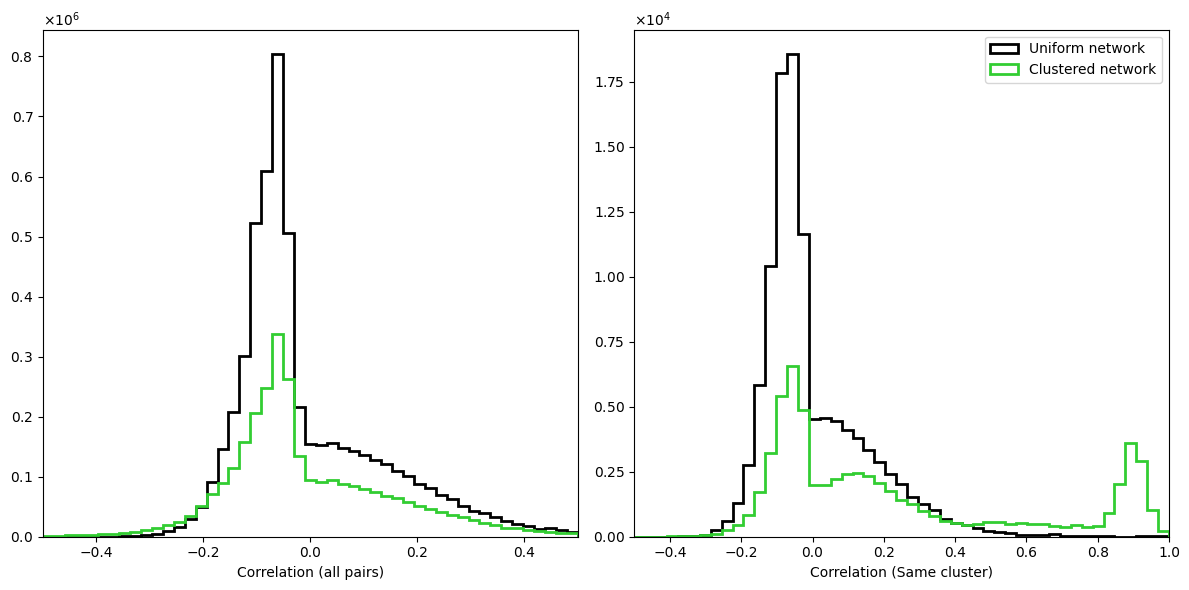

In [40]:
#plot step histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

bins1 = np.linspace(-0.5, 0.5, 50)
plot_corr_experiments(axes[0], bins1, uniform_coeffs, clustered_coeffs, 6, "Correlation (all pairs)")

bins2 = np.linspace(-0.5, 1, 50)
plot_corr_experiments(axes[1], bins2, uniform_same_cluster_coeffs, clustered_same_cluster_coeffs, 4, "Correlation (Same cluster)")

plt.legend()
plt.tight_layout()
plt.show()